In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import optuna
from sklearn.metrics import accuracy_score
from scipy.stats import t
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm, laplace
from sklearn.metrics import ConfusionMatrixDisplay
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import classification_report
from sklearn.metrics import classification_report, cohen_kappa_score, log_loss, f1_score
import subprocess
import sys
from pathlib import Path
import re
import mlflow


import warnings
warnings.filterwarnings("ignore")


pd.set_option('display.max_columns', 50)

c:\Users\peter\anaconda3\envs\torchgpu\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<div style="background:blue; color:white; padding:10px; margin-bottom:10px;">

# Ml Flow Setup
</div>


 - Change Name Below, change params
 - Save File
 - Run All

In [ ]:
runName = "Exp_Sep27_9.51"

In [3]:
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("Step4 LSTM")

<Experiment: artifact_location='mlflow-artifacts:/1', creation_time=1790543163369, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1790543163369, lifecycle_stage='active', name='Step4 LSTM', tags={}, trace_location=None, workspace='default'>

In [4]:
#Save exact code + DVC pointer BEFORE training
subprocess.run(["git", "add", "Step4.ipynb", "data.csv.dvc"], check=True)

hasChanges = subprocess.run(["git", "diff", "--cached", "--quiet"]).returncode != 0

if hasChanges:
    subprocess.run(["git", "commit", "-m", f"Code for {runName}"], check=True)
    subprocess.run(["git", "push"], check=True)

gitCommit = subprocess.check_output(["git", "rev-parse", "HEAD"], text=True).strip()
print("Git commit:", gitCommit)

Git commit: 2321d0f32dba0c5bbaf38e8eb8496bd259ad8a06


 - This replaces the PoweShell Commands
    - Terminal
	    - git add Step4.ipynb data.csv.dvc
		- git commit -m "Code for Exp_Sep27_8.45"
        - git push

<div style="background:blue; color:white; padding:10px; margin-bottom:10px;">

# Open File 
</div>


In [5]:
#OpenFile
df = pd.read_csv('data.csv')

#SetIndex
df['time'] = pd.to_datetime(df['time'])
df = df.set_index('time', drop=True)

#Print
pd.concat([df.head(2), df.tail(2)])

,time.1,mid_last,priceBid_last,priceAsk_last,BidAskSprd_N,BidAskSprd_N_d,sizeSprd_L,sizeSprd_L_d,vlm_LN,vlmSigned_L,ofi_10,ofi_30,ofi_60,nTrades,nQuotes,retAdj_last
time,,,,,,,,,,,,,,,,
2025-07-16 09:40:00,2025-07-16 09:40:00,623.745,623.74,623.75,0.8112,0.0000,0.1155,0.0000,-0.4600,7.4043,7.4043,7.4043,7.4043,19,486,0.0000
2025-07-16 09:40:01,2025-07-16 09:40:01,623.735,623.73,623.74,0.7670,-0.0442,0.3036,0.1881,0.4039,7.0040,14.4083,14.4083,14.4083,12,450,-1.6032
2026-09-10 15:49:58,2026-09-10 15:49:58,758.120,758.11,758.13,1.1171,0.0096,0.3151,0.4944,-0.2835,0.0000,17.6976,9.5145,-19.0750,2,50,1.3191
2026-09-10 15:49:59,2026-09-10 15:49:59,758.095,758.08,758.11,1.5017,0.3846,0.4824,0.1672,0.1560,5.8201,17.3628,10.7195,-18.5582,10,58,-3.2977


In [6]:
df.isna().sum().sum()

np.int64(0)

<div style="background:blue; color:white; padding:10px; margin-bottom:10px;">

# Fwd Rets
</div>


In [7]:
h1 = 5
h2 = 10

df['ret1'] = np.log(df['mid_last'].shift(-h1) / df['mid_last']) * 100000
df['ret2'] = np.log(df['mid_last'].shift(-h2) / df['mid_last'].shift(-h1)) * 100000

sameDay1 = df.index.date == df.index.to_series().shift(-h1).dt.date
sameDay2 = df.index.date == df.index.to_series().shift(-h2).dt.date

df.loc[~sameDay1, 'ret1'] = np.nan
df.loc[~sameDay2, 'ret2'] = np.nan

df = df.dropna(subset=['ret1','ret2'])

<div style="background:blue; color:white; padding:10px; margin-bottom:10px;">

# Split Data Set
</div>


In [8]:
df_train=df.loc[:'2025-11-30'].copy()
df_test=df.loc['2025-12-01':'2026-02-28'].copy()

#PrintShapes
#print(f"Full shape:  {df.shape}"); print(f"Train shape: {df_train.shape}"); print(f"Test shape:  {df_test.shape}")

df.shape[0] - df_train.shape[0] - df_test.shape[0]

2973460

<div style="background:blue; color:white; padding:10px; margin-bottom:10px;">

# Fwd 2
</div>


In [9]:
gamma1 = df_train['ret1'].abs().quantile(0.33)
gamma2 = df_train['ret2'].abs().quantile(0.33)

#Train
df_train['target1'] = np.select([df_train['ret1'] < -gamma1, df_train['ret1'] > gamma1], [-1, 1], default=0)
df_train['target2'] = np.select([df_train['ret2'] < -gamma2, df_train['ret2'] > gamma2], [-1, 1], default=0)
df_train['target'] = (df_train['target1'] + 1) * 3 + (df_train['target2'] + 1)

#Test
df_test['target1'] = np.select([df_test['ret1'] < -gamma1, df_test['ret1'] > gamma1], [-1, 1], default=0)
df_test['target2'] = np.select([df_test['ret2'] < -gamma2, df_test['ret2'] > gamma2], [-1, 1], default=0)
df_test['target'] = (df_test['target1'] + 1) * 3 + (df_test['target2'] + 1)

<div style="background:blue; color:white; padding:10px; margin-bottom:10px;">

# Trace Windows
</div>


 - Zero For y_train_seq is -1 for target

<div style="background:blue; color:white; padding:10px; margin-bottom:10px;">

# Run Simple LSTM With Minibatching On Cuda 1
</div>


##### Model

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

#RandomSeed
import random
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

#Settings
nLags = 30
epochs = 2
batchSize = 4096
hidden_size = 128
num_layers = 2
learn_rate = 0.001
dev = 'cuda'
features = ['vlmSigned_L','BidAskSprd_N','sizeSprd_L','ofi_10','ofi_30','ofi_60','BidAskSprd_N_d','sizeSprd_L_d','retAdj_last']

########################################################
# Train Data
########################################################
X_train = df_train[features].values
y_train = df_train['target'].values
X_train_seq = np.array([X_train[i-nLags:i] for i in range(nLags, len(X_train))])
y_train_seq = y_train[nLags-1:len(X_train)-1]

########################################################
# Test Data
########################################################
X_test = df_test[features].values
y_test = df_test['target'].values
X_test_seq = np.array([X_test[i-nLags:i] for i in range(nLags, len(X_test))])
y_test_seq = y_test[nLags-1:len(X_test)-1]

#StandardizeUsingTrainingData
scaler = StandardScaler()
scaler.fit(X_train_seq.reshape(-1, len(features)))
X_train_scaled = scaler.transform(X_train_seq.reshape(-1, len(features))).reshape(X_train_seq.shape)
X_test_scaled = scaler.transform(X_test_seq.reshape(-1, len(features))).reshape(X_test_seq.shape)

########################################################
# Convert to tensors
########################################################
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_seq, dtype=torch.long)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test_seq, dtype=torch.long)

########################################################
# Model
########################################################
lstm = nn.LSTM(len(features), hidden_size,num_layers=num_layers, batch_first=True).to(dev)
fc = nn.Linear(hidden_size, 9).to(dev)
optimizer = torch.optim.Adam(list(lstm.parameters()) + list(fc.parameters()),lr=learn_rate)
#LossFunct
loss_fn = nn.CrossEntropyLoss()

########################################################
# Train
########################################################
#Dedicated Generator
g = torch.Generator()
g.manual_seed(seed)

#TrainLoaderWithGenerator
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batchSize, shuffle=True, generator=g )

for epoch in range(epochs):
    total_loss, n = 0.0, 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(dev), y_batch.to(dev)
        optimizer.zero_grad()
        out, _ = lstm(X_batch)
        pred = fc(out[:, -1, :])
        loss = loss_fn(pred, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * y_batch.size(0)
        n += y_batch.size(0)
    print(epoch + 1, total_loss / n)

########################################################
# Predict on test
########################################################
test_loader = DataLoader(TensorDataset(X_test_t), batch_size=batchSize)
preds = []
with torch.no_grad():
    for (X_batch,) in test_loader:
        out, _ = lstm(X_batch.to(dev))
        preds.append(fc(out[:, -1, :]).argmax(1).cpu())

########################################################
# Results
########################################################
pred = torch.cat(preds).numpy()
y_true = y_test_seq

1 2.1080739052005746
2 2.0971570613552144


### Eval

Accuracy: 0.18396702091113598
              precision    recall  f1-score   support

         D-D       0.19      0.11      0.14    181483
         D-0       0.12      0.01      0.02    120071
         D-U       0.16      0.08      0.11    187434
         0-D       0.00      0.00      0.00    120062
         0-0       0.20      0.78      0.32    148262
         0-U       0.00      0.00      0.00    116457
         U-D       0.17      0.50      0.25    187393
         U-0       0.12      0.01      0.02    116512
         U-U       0.16      0.01      0.02    175911

    accuracy                           0.18   1353585
   macro avg       0.12      0.17      0.10   1353585
weighted avg       0.13      0.18      0.11   1353585



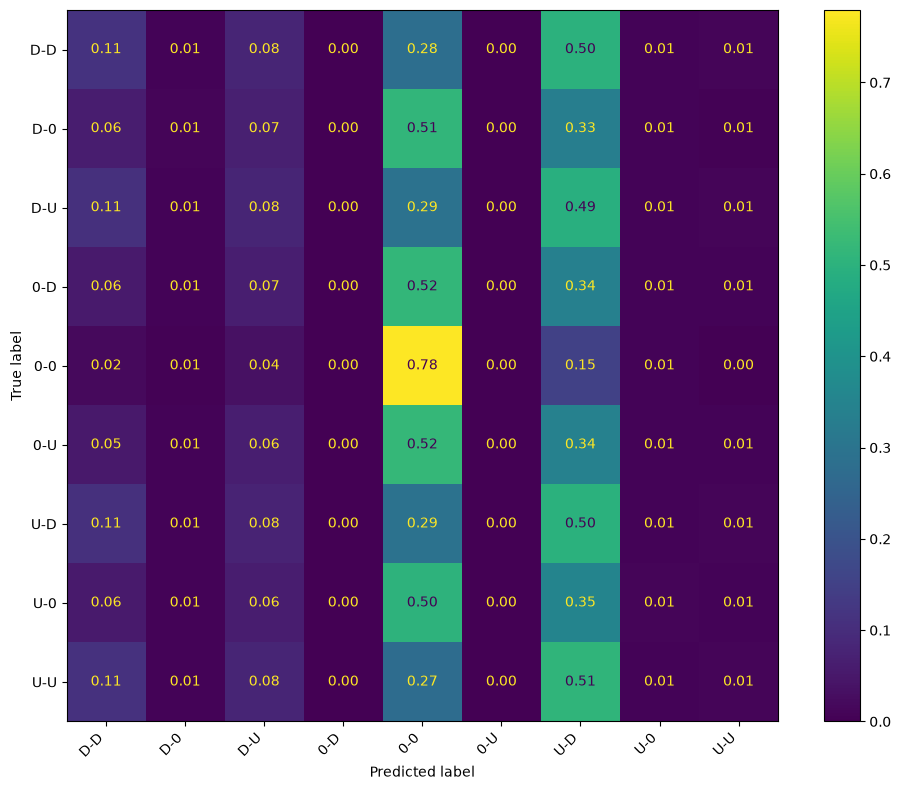

In [11]:
print("Accuracy:", accuracy_score(y_true, pred))
names = ['D-D','D-0','D-U','0-D','0-0','0-U','U-D','U-0','U-U']
print(classification_report(y_true, pred, labels=range(9), target_names=names))

fig, ax = plt.subplots(figsize=(10,8))

ConfusionMatrixDisplay.from_predictions(y_true, pred, labels=range(9), display_labels=names, normalize='true', values_format='.2f', ax=ax)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Detect Overfit

In [12]:
########################################################
# Check Train Vs Test Overfit
########################################################
train_eval_loader = DataLoader( TensorDataset(X_train_t), batch_size=batchSize )

train_preds = []

with torch.no_grad():
    for (X_batch,) in train_eval_loader:
        out, _ = lstm(X_batch.to(dev))
        train_preds.append(fc(out[:, -1, :]).argmax(1).cpu())

pred_train = torch.cat(train_preds).numpy()
y_train_true = y_train_seq

a = classification_report(y_train_true, pred_train, labels=range(9)).splitlines()
b = classification_report(y_true, pred, labels=range(9)).splitlines()
w = max(map(len, a)) + 4

print(f"{'TRAIN':<{w}}TEST")
print("\n".join(map(lambda p: f"{p[0]:<{w}}{p[1]}", zip(a, b))))


TRAIN                                                    TEST
              precision    recall  f1-score   support                  precision    recall  f1-score   support
                                                         
           0       0.18      0.12      0.14    248635               0       0.19      0.11      0.14    181483
           1       0.13      0.01      0.02    201134               1       0.12      0.01      0.02    120071
           2       0.14      0.07      0.09    262327               2       0.16      0.08      0.11    187434
           3       0.00      0.00      0.00    203516               3       0.00      0.00      0.00    120062
           4       0.22      0.81      0.35    296389               4       0.20      0.78      0.32    148262
           5       0.00      0.00      0.00    203079               5       0.00      0.00      0.00    116457
           6       0.16      0.45      0.24    259937               6       0.17      0.50      0.25   

<div style="background:blue; color:white; padding:10px; margin-bottom:10px;">

# Save MlFlow
</div>


In [13]:
from sklearn.metrics import accuracy_score, f1_score

train_acc = accuracy_score(y_train_true, pred_train)
test_acc = accuracy_score(y_true, pred)

train_f1 = f1_score(y_train_true, pred_train, average='macro')
test_f1 = f1_score(y_true, pred, average='macro')

In [14]:

#GetVersions
gitCommit = subprocess.check_output(["git", "rev-parse", "HEAD"], text=True).strip()   #GetGitHashNumberWeJustCreatedInTerminal
dvcText = Path("data.csv.dvc").read_text()
dvcHash = re.search(r"md5:\s*([0-9a-f]+)", dvcText).group(1)

with mlflow.start_run(run_name=runName):

    #SaveParams
    mlflow.log_params({ "nLags": nLags, "epochs": epochs, "batchSize": batchSize, "hidden_size": hidden_size, "num_layers": num_layers, "learn_rate": learn_rate, "seed": seed, "h1": h1, "h2": h2, "features": ",".join(features), "train_end": "2025-11-30", "test_start": "2025-12-01", "test_end": "2026-02-28" })

    #SaveResults
    mlflow.log_metrics({ "train_accuracy": train_acc, "test_accuracy": test_acc, "train_macro_f1": train_f1, "test_macro_f1": test_f1 })

    #SaveVersions
    mlflow.set_tag("git_commit", gitCommit)
    mlflow.set_tag("dvc_data_hash", dvcHash)
    mlflow.log_artifact("data.csv.dvc", artifact_path="data")

    #SaveHtmlArtifact
    subprocess.run([ sys.executable, "-m", "jupyter", "nbconvert", "--to", "html", "--output", f"{runName}.html", "--output-dir", "results", "Step4.ipynb" ], check=True)

    #AttachHtmlArtifact
    mlflow.log_artifact(f"results/{runName}.html", artifact_path="notebook")

🏃 View run Exp_Sep27_9.47 at: http://127.0.0.1:5000/#/experiments/1/runs/157e4ad3273a4ba2a1c2063084a0adfe
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
